<a href="https://colab.research.google.com/github/Trace55/NFL_4th_Down_ML/blob/main/NFL_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Predicting NFL 4th down Descisions
In this notebook, the NFL play by play data from kaggle at this url https://www.kaggle.com/maxhorowitz/nflplaybyplay2009to2016 is taken and applied to a SVM, KNN, Naive Bayes and Random Forest to find a model that best predicts what a coach will decide to do when it comes to a 4th down.

If you are unfamiliar with football please read**. Within the game of football an offensive team that has the ball must advance a total of 10 yards within four tries. After the fourth attempt offensive posession is switched (defensive ins now on offense and vise versa). In this notebook, the main concern is what will happen on the 4th down. There are only three main plays a coach can deploy. One is called a punt, in which the offensive team sacrifices their fourth down to put the opposite team in a further position downfield making it harder to score. The next is that they can use their fourth turn to "go for it" and try to get the rest of the yards needed. The downfall of this play is that if the team does not get the needed yards, the opposite team will have a better field position to score. The last is that if the team is close enough to their end zone (generally within 45 yards), the offensive team can kick a "field goal" and score three points. After this play the defensive team receives the ball in a kickoff. In other words, the possessions of the teams are reset and the previous team that kicked the field goal is now on defense and vise versa. 

# Pre-processing

In the cells below the data is being read in.

In [ ]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

In [ ]:
#path = "/content/drive/MyDrive/NFL/NFL Play by Play 2009-2016 (v3).csv"
path = 'NFL Play by Play 2009-2016 (v3).csv'
df = pd.read_csv(path)

/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (25,51) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


Below all irrelevent columns are being dropped. Most of these include results of the play. In this study we are trying to predict what will happen before the starts play. If some of the abreviations of the following dropped columns are confusing one can find an entire explaination of all variabels at this url https://github.com/ryurko/nflscrapR-data/tree/master/legacy_data . 

In [ ]:
df1 = df.drop(columns = ['time','TwoPointConv', 'PlayAttempted', 'ReturnResult','Returner','BlockingPlayer',
                'Tackler1','Tackler2','Fumble','RecFumbTeam','RecFumbPlayer','DefTwoPoint','Safety','Onsidekick',
                'PassAttempt','ExPointResult', 'Date', 'YardsAfterCatch','QBHit','PassLocation', 'InterceptionThrown',
                'Interceptor', 'Rusher_ID','RushAttempt','RunLocation', 'RunGap','Receiver_ID',
                'Challenge.Replay', 'ChalReplayResult','ChalReplayResult','PenalizedTeam', 'PenaltyType',
                'PenalizedPlayer','PuntResult','PassOutcome','PassLength', 'PosTeamScore', 'DefTeamScore',
                'AirYards', 'desc','GameID','Passer_ID', 'Yards.Gained', 'sp', 'ydsnet', 'AbsScoreDiff','Passer',
                'Rusher', 'Receiver','Reception','FieldGoalResult', 'TimeUnder','PlayTimeDiff','SideofField','yrdln',
                'FirstDown', 'Penalty.Yards', 'Sack',
                    
                #dropping probabilities by other model
                'No_Score_Prob', 'Opp_Field_Goal_Prob','Opp_Safety_Prob', 'Opp_Touchdown_Prob', 'Field_Goal_Prob', 'Safety_Prob','Touchdown_Prob',
                'ExpPts', 'EPA', 'airEPA', 'yacEPA', 'Home_WP_pre', 'Away_WP_pre', 'Home_WP_post','Away_WP_post', 'Win_Prob',
                'WPA','airWPA','yacWPA','TwoPoint_Prob','ExPoint_Prob'
                    ])

Here the data is filitered to 4th down (as that is the only down we care about in this study). Then within the data there is a small subset of the plays were a QB Kneel takes place or far enough into a play a time out is called, this happend 23 times out of a total of 32,099 4th downs. These types of plays are not taken into consideration for this study and are dismissed. In additon, 'No play' is added into the dropping of these types of 4th downs. A 'No Play' happens when a penalty occurs before the play starts or other reasons where the play does not take place.


In [ ]:
mask = (df1['down'] == 4) 
fd = df1[mask].copy()
mask1 = (fd['PlayType'] == 'Timeout') | (fd['PlayType'] == 'QB Kneel') | (fd['PlayType'] == 'No Play')
print(fd[mask1].shape , fd.shape)
i = fd[mask1].index
fd1 = fd.drop(i).reset_index()

(1456, 24) (32099, 24)


In the cell below all the types of plays that fall under the WFI("Went for it ") catagory are renamed. 

In [ ]:
fd2 = fd1.drop(columns = ['index', 'down'])
y = fd2['PlayType']

yf = y.replace('Sack', 'WFI')
yf2 = yf.replace('Pass', 'WFI')
yf3 = yf2.replace('Field Goal', 'FG')
Y = yf3.replace('Run', 'WFI')
fd2['PT'] = Y

Drop more columns, here this is saying that the model will assume all coaches act the same and timeouts dont signify anything within the 4th down. 

In [ ]:
fd2 = fd2.drop(columns = ['Touchdown','PlayType','HomeTeam','AwayTeam','posteam','DefensiveTeam','Timeout_Team', 
                          'posteam_timeouts_pre','HomeTimeouts_Remaining_Pre',
                          'AwayTimeouts_Remaining_Pre','HomeTimeouts_Remaining_Post','AwayTimeouts_Remaining_Post'])

Running this cell shows the weights of the 3 target variables

In [ ]:
Mix = fd2.copy()
k = Mix.shape[0]
m = Mix['PT'] == 'FG'
m1 = Mix['PT'] == 'Punt'
m2 = Mix['PT'] == 'WFI'
Mix[m].shape[0]/k , Mix[m1].shape[0]/k, Mix[m2].shape[0]/k

(0.23708514179421075, 0.638024997552459, 0.12488986065333028)

This cell results in our final data set that will be used for the models


In [ ]:
mix = Mix.drop(columns = ['qtr','FieldGoalDistance','Accepted.Penalty','Timeout_Indicator','GoalToGo','Drive',
                         ])
mix

,TimeSecs,yrdline100,ydstogo,ScoreDiff,Season,PT
0,3507.0,56.0,8,0.0,2009,Punt
1,3394.0,96.0,8,0.0,2009,Punt
2,3205.0,41.0,21,0.0,2009,Punt
3,3108.0,19.0,7,0.0,2009,FG
4,3002.0,79.0,16,0.0,2009,Punt
...,...,...,...,...,...,...
30638,1307.0,65.0,15,-3.0,2016,Punt
30639,1011.0,58.0,10,3.0,2016,Punt
30640,890.0,69.0,13,-3.0,2016,Punt
30641,467.0,36.0,10,-9.0,2016,FG


This cell results in our split up data so we will have a hold-out set to guage how well our models perform on data not seen.



In [ ]:
xc = mix.drop(columns=['PT'])
yc = mix['PT']

holdout_frac = 0.1
splits = 10
holdout_splitter = StratifiedShuffleSplit(n_splits=splits, test_size = holdout_frac, random_state=42)
model_idx, holdout_idx = next(holdout_splitter.split(xc, yc))


X_m, y_m = xc.iloc[model_idx]  , yc.iloc[model_idx]
X_h, y_h = xc.iloc[holdout_idx], yc.iloc[holdout_idx]

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, make_scorer


In [ ]:
d = X_m.shape[1]

The rest of the code below are the algorithms ran on the data. These cells take time to run! To see best model and results skip to the 'Further Analysis' section.

# Random Forest


In [ ]:
pipe = Pipeline([('classify', RandomForestClassifier())])

hyperparams = {
               'classify__max_depth' : np.arange(1,40),
               'classify__min_samples_split'  : np.arange(2,8),
               'classify__random_state': [5364]
              }

gridrf = GridSearchCV(pipe, hyperparams, cv=10, scoring= 'f1_macro').fit(X_m, y_m)

In [ ]:
res = gridrf.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - .001
mask = df['score'] > thres
results_rf_40 = df[mask]
results_rf_40

,classify__max_depth,classify__min_samples_split,classify__random_state,score
64,11,6,5364,0.864991
65,11,7,5364,0.865017
67,12,3,5364,0.865291
70,12,6,5364,0.865881
71,12,7,5364,0.865841
77,13,7,5364,0.865590
83,14,7,5364,0.865106
89,15,7,5364,0.865449
94,16,6,5364,0.865104
107,18,7,5364,0.865644


We can see that from a max of depth of 11-30 has similar scores. This is similar with the min sample splits parameter. Below is where I narrow down the model to prevent over fitting.

In [ ]:
pipe = Pipeline([('classify', RandomForestClassifier())])

hyperparams = {
               'classify__max_depth' : np.arange(2,15),
               'classify__min_samples_split'  : np.arange(2,4),
               'classify__random_state': [5364]
              }

gridrf = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_macro').fit(X_m, y_m)

In [ ]:
res = gridrf.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - .05
mask = df['score'] > thres
results_rf_15 = df[mask]
results_rf_15

,classify__max_depth,classify__min_samples_split,classify__random_state,score
6,5,2,5364,0.836887
7,5,3,5364,0.836746
8,6,2,5364,0.846082
9,6,3,5364,0.846187
10,7,2,5364,0.853694
11,7,3,5364,0.853049
12,8,2,5364,0.858438
13,8,3,5364,0.859418
14,9,2,5364,0.861355
15,9,3,5364,0.861977


Here ill pick the max depth of 11 and min split of 2 for the "best" model.  Other algorithems are ran below, go to "Further Analysis" to see an evaluation of this model.

# K Nearest Neighbors

In [ ]:
pipe = Pipeline([('scale', StandardScaler()),
                 ('dim_reduce', PCA()),
                 ('classify'  , KNeighborsClassifier())
                 ])

hyperparams = {
               'dim_reduce__n_components' : np.arange(1, d+1),
               'classify__n_neighbors' : np.arange(1, 35),
               'classify__weights' : ['uniform', 'distance'],
               'classify__p' : np.arange(1, 6)
            }
gridk = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_macro').fit(X_m, y_m)

In [ ]:
res = gridk.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - .001
mask = df['score'] > thres
results_knn = df[mask]
results_knn

,classify__n_neighbors,classify__p,classify__weights,dim_reduce__n_components,score
519,11,2,distance,5,0.811006
579,12,3,distance,5,0.811112
619,13,2,distance,5,0.810873
629,13,3,distance,5,0.811429
669,14,2,distance,5,0.811234
679,14,3,distance,5,0.810928
719,15,2,distance,5,0.810953
809,17,1,distance,5,0.810935
969,20,2,distance,5,0.810513
1019,21,2,distance,5,0.810690


Here we see that even with a large amount of neighbors, the score doesnt come close to the Random Forest.

# Naive Bayes


Gaussian Naive Bayes assumption is that all the features are normally distributed. Below you can see that they are in fact not normally distributed and thus a power transform is applied. However, our variables do not transform well
and thus a bad score for Naive Bayes



TimeSecs


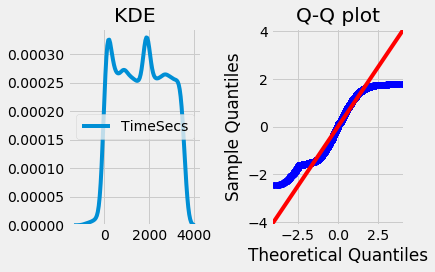

yrdline100


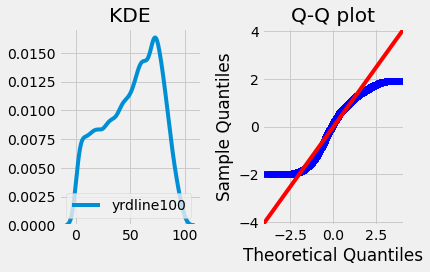

ydstogo


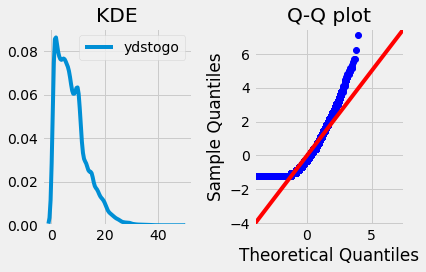

ScoreDiff


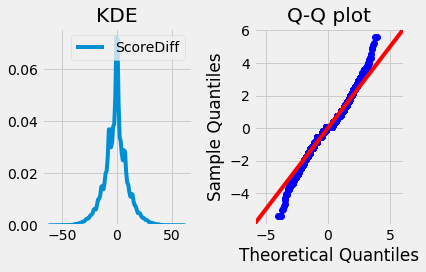

Season


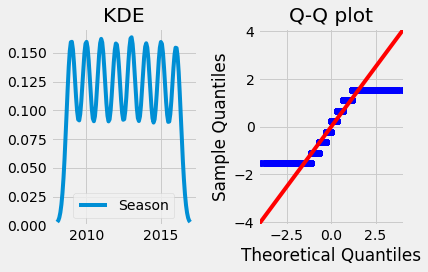

In [ ]:
import statsmodels.api as sm

def plot_density(x):
    print(x.name)
    plt.style.use('fivethirtyeight')
    fig, ax = plt.subplots(ncols=2)
    sns.kdeplot(x, ax=ax[0])
    ax[0].set_title(f'KDE')
    sm.qqplot(x, ax=ax[1], line="45", fit=True)
    ax[1].set_title(f'Q-Q plot')
    plt.tight_layout()
    plt.show()

X_m.apply(plot_density);

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer().fit(X_m)
Z_m = pt.transform(X_m)
Z_m = pd.DataFrame(Z_m,columns=X_m.columns)


TimeSecs


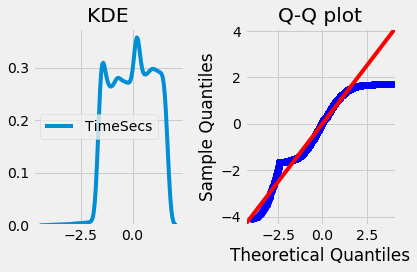

yrdline100


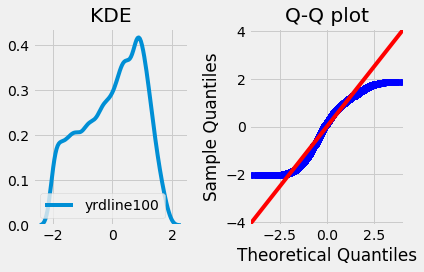

ydstogo


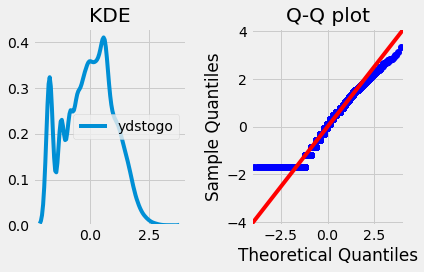

ScoreDiff


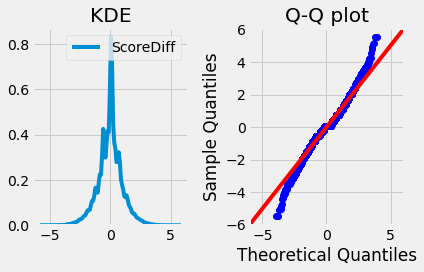

Season


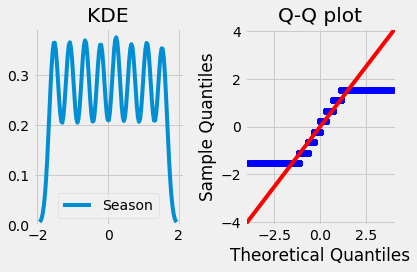

In [ ]:
Z_m.apply(plot_density);

In [ ]:
pipe = Pipeline([('scale', StandardScaler()),
                 ('classify'  , GaussianNB())
                 ])

hyperparams = {
               
            }
gridnb = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_macro').fit(Z_m, y_m)

In [ ]:
res = gridnb.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - 10
mask = df['score'] > thres
results_NB_ma = df[mask]
results_NB_ma

,score
0,0.762188


As seen above, when our features are transformed they do not normalize well. Since one of the assumptions for GaussianNB is that the features are approximatly normal, we get a bad score.

# Support Vector Machine

In [ ]:
pipe = Pipeline([('scale', MaxAbsScaler()),
                 ('clf', SVC(decision_function_shape='ovr')),])

hyperparams = [{'clf__kernel' : ['linear']},
               ]

gridsvm = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_macro').fit(X_m, y_m)

In [ ]:
res = gridsvm.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - 10
mask = df['score'] > thres
results_svm_linear = df[mask]
results_svm_linear

,clf__kernel,score
0,linear,0.741078


Checking both "one vs the rest" and "one vs one"


In [ ]:
pipe = Pipeline([('scale', MaxAbsScaler()),
                 ('clf', SVC(decision_function_shape='ovo')),])

hyperparams = [{'clf__kernel' : ['linear']},
               ]

gridsvmo = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_macro').fit(X_m, y_m)

In [ ]:
res = gridsvmo.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - 10
mask = df['score'] > thres
results_svm_linear_ovr = df[mask]
results_svm_linear_ovr

,clf__kernel,score
0,linear,0.741078


We get the same score for both? The rest of the cells below is running the rest of the kernels for SVM. The default option here is 'ovr'.   

In [ ]:
pipe = Pipeline([('scale', StandardScaler()),
                 ('clf', SVC(kernel='poly')),])

hyperparams = [{'clf__C' : [1,10,100] ,
                 'clf__degree' : np.arange(2,8),
               #'clf__coef0' : np.arange(1,2),
               #'clf__gamma' : np.arange(1,2),}
}
               ]
gridp = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_macro').fit(X_m, y_m)

SVM is by far one of the more powerful algorithems done in this note book. Unfortunatly, a technical difficulty occured when trying to gridsearch over the gamma and coefficient of these kernels. The only hyperparmater that would work with me was the strength of regularization.

In [ ]:
res = gridp.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - 1
mask = df['score'] > thres
results_svm_poly = df[mask]
results_svm_poly

,clf__C,clf__degree,score
0,1,2,0.484299
1,1,3,0.767198
2,1,4,0.596594
3,1,5,0.772761
4,1,6,0.610269
5,1,7,0.762261
6,10,2,0.484496
7,10,3,0.774198
8,10,4,0.598504
9,10,5,0.789957


In [ ]:
pipe = Pipeline([('scale', StandardScaler()),
                 ('clf', SVC(kernel='rbf')),])

hyperparams = [{'clf__C' : [1,10,100] ,
                 #'clf__degree' : np.arange(2,8),
               'clf__coef0' : [1.0,1.25],
               #'clf__gamma' : np.arange(1,2),}
}
               ]
gridp = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_macro').fit(X_m, y_m)

In [ ]:
res = gridp.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - 1
mask = df['score'] > thres
results_svm_rbf = df[mask]
results_svm_rbf

,clf__C,clf__coef0,score
0,1,1.00,0.827441
1,1,1.25,0.827441
2,10,1.00,0.842290
3,10,1.25,0.842290
4,100,1.00,0.843484
5,100,1.25,0.843484


In [ ]:
pipe = Pipeline([('scale', StandardScaler()),
                 ('clf', SVC(kernel='sigmoid')),])

hyperparams = [{'clf__C' : [1,10,100] ,
                 #'clf__degree' : np.arange(2,8),
               #'clf__coef0' : np.arange(1,2),
               #'clf__gamma' : np.arange(1,2),}
}
               ]
gridp = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_macro').fit(X_m, y_m)

In [ ]:
res = gridp.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() - 1
mask = df['score'] > thres
results_svm_sigmoid = df[mask]
results_svm_sigmoid

,clf__C,score
0,1,0.618107
1,10,0.616712
2,100,0.615677


For the above models, the radial basis function kernel does the best. Howver it does not beat the random forest.



# Further Analysis

The best model from above is the Randomforest and thus we look into the errors the model has and see if there is an approch we can take to better the model. Below is code to make a confusion matrix which will give us a visualization of the errors on the hold out set.  The set of data the model has not yet seen.

In [ ]:
def display_confusion_matrixf(y_true, y_pred):
    """Pretty display for confusion matrix"""
    #in this variation use gridsearch to calc the score
    
    labels = y_true.unique()
    cf = confusion_matrix(y_true, y_pred, labels)
    #grid = GridSearchCV(pipe, hyperparams, cv=10, scoring= 'f1_weighted')
    rc1,rc2,rc3 = np.sum(cf,axis=0)
    pr1,pr2,pr3 = np.sum(cf,axis=1)

    pres1 = cf[0,0] /pr1
    pres2 = cf[1,1] /pr2
    pres3 = cf[2,2]/ pr3

    recal1 = cf[0,0] /rc1
    recal2 = cf[1,1] /rc2
    recal3 = cf[2,2] /rc3

    f1_a = 2*(pres1*recal1)/(pres1+recal1)
    f1_b = 2*(pres2*recal2)/(pres2+recal2)
    f1_c = 2*(pres3*recal3)/(pres3+recal3)
    mac = 100 *(f1_a+f1_b+f1_c)/3
    
    df = pd.DataFrame(cf, columns=labels, index=labels)
    df.index.name = 'Actual'
    df.columns.name = 'Predicted'
    plt.figure(figsize = (10,7))
    plt.title(f'f1= {mac:.2f}%')
    sns.set(font_scale=1.4)#for label size
    sns.heatmap(df, cmap="Purples", annot=True,annot_kws={"size": 16})# font size
    plt.show()

    idx = y_true != y_pred
    df_errors = pd.DataFrame()
    df_errors['y_true'] = y_true[idx]
    df_errors['y_pred'] = y_pred[idx]
    display(df_errors)
    return df, df_errors

In [ ]:
pipe = Pipeline([('classify', RandomForestClassifier())])

hyperparams = {
               'classify__max_depth' : [11],
               'classify__min_samples_split'  : [2],
               'classify__random_state': [5364]
              }

gridrf = GridSearchCV(pipe, hyperparams, cv=10, scoring='f1_weighted').fit(X_m, y_m)

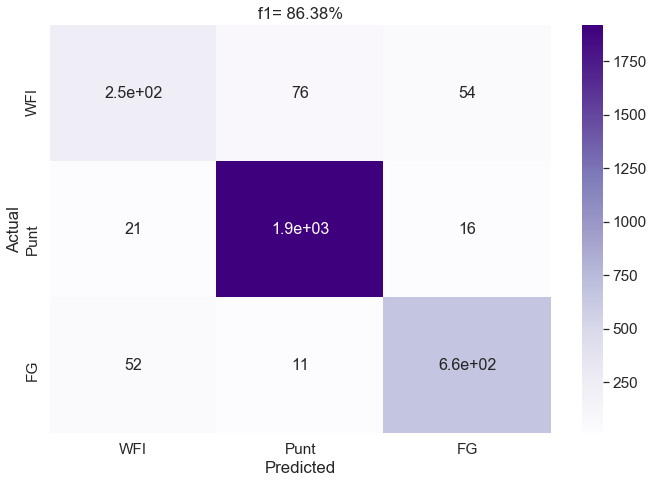

,y_true,y_pred
2513,FG,WFI
1661,Punt,FG
19061,Punt,FG
30612,WFI,Punt
23683,Punt,WFI
...,...,...
19118,FG,Punt
16309,WFI,Punt
10741,WFI,Punt
11160,WFI,Punt


In [ ]:
res = gridrf.cv_results_
df = pd.DataFrame(res['params'])
df['score'] = res['mean_test_score']
thres = df['score'].max() -1
mask = df['score'] > thres
rf = df[mask]

y_pred = gridrf.predict(X_h)
c,f = display_confusion_matrixf(y_h,y_pred)

We can see that the score is very similar to the model that trained on the traininng set (86.44%), so our model does continue to do well on new data. Note that the majority of errors happen when the model predicts a punt but what actually happend is that they went for it. This can be justified as human behavior were coaches are being riskier than normal.

Below we will go back into the origianl data and look a what happens in the "description" column of the data.

In [ ]:
path = "NFL Play by Play 2009-2016 (v3).csv"
pf = pd.read_csv(path)

mask = (pf['down'] == 4) 
fd = pf[mask].copy()
mask1 = (fd['PlayType'] == 'Timeout') | (fd['PlayType'] == 'QB Kneel') | (fd['PlayType'] == 'No Play')
print(fd[mask1].shape , fd.shape)
i = fd[mask1].index
fd1 = fd.drop(i).reset_index()
pf = fd1

/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (25,51) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


(1456, 102) (32099, 102)


Below is code that were I can look into a sample the model mis-predicts on.

In [ ]:
fn = f.index
G = pd.DataFrame()

In [ ]:
fn = f.index
G = pd.DataFrame()

for i in fn:
    a = pf[['desc','ydstogo','yrdline100','ScoreDiff']].loc[[i]]
    b = f.loc[[i]]
    apb = pd.concat([a, b], axis=1, join='outer')
    B = G.append([apb])
    G = B
B.head(30)

,desc,ydstogo,yrdline100,ScoreDiff,y_true,y_pred
2513,"(1:05) K.Brown 33 yard field goal is GOOD, Center-J.Dreessen, Holder-M.Turk.",1,15.0,10.0,FG,WFI
1661,"(2:53) S.Weatherford punts 22 yards to MIA 13, Center-J.Dearth, fair catch by D.Bess.",6,35.0,0.0,Punt,FG
19061,"(1:10) (Punt formation) S.Lanning punts 33 yards to end zone, Center-C.Yount, Touchback.",18,33.0,-14.0,Punt,FG
30612,"(5:06) (Punt formation) J.Ryan Aborted. N.Frese FUMBLES at SEA 0, ball out of bounds in End Zone, SAFETY.",10,86.0,8.0,WFI,Punt
23683,"(2:06) B.Pinion punts 39 yards to ARI 15, Center-K.Nelson, fair catch by B.Golden.",5,54.0,-38.0,Punt,WFI
3183,"(2:39) D.Jones punts 37 yards to HOU 15, Center-R.Neill, downed by SL-J.Kent.",10,52.0,-3.0,Punt,WFI
4319,(:03) (Punt formation) M.Turk left end to HOU 9 for -27 yards (C.Horton).,2,64.0,0.0,WFI,Punt
18118,(6:14) (Shotgun) C.Kaepernick pass incomplete short left to F.Gore.,4,34.0,11.0,WFI,FG
4510,"(:17) M.Prater 25 yard field goal is GOOD, Center-L.Paxton, Holder-B.Colquitt.",1,7.0,-13.0,FG,WFI
8107,(7:37) (Shotgun) T.Romo pass short right to J.Witten ran ob at SF 25 for 9 yards [J.Smith]. Caught at SF 25. 0-yds YAC,5,34.0,-10.0,WFI,FG


As one can see above these are mostly outliers, this model mis-predicts on senerios that rarely happen. For example on index number 30612, the team does go to kick a punt but the kicker misses the snap and fumbles it, in which case the data calls it a WFI as they never got the ball off. Also, within the National Football Leauge a field goal (FG) will take place if a team has passed the 40 or 45 yard line. In the above data frame one can see that instead of a FG being kicked some teams are kicking punts. This is perhapse due to their placekicker being injured. This can also be said about the situation were they only have a yard to go and they punt it because the coach being risk adverse.

To continue imporvments on this model, rank within conference and average offensive yards in the game would be added. If teams are fighting for a seed in the playoffs, coaches tend to be riskier on 4th down. This is due to that if they loose, they will not continue to play and their season is over.